# Ordonnancement par chemin critique du lancement d'un produit d'assurance automobile

## Synthèse

Le lancement d'un produit d'assurance automobile pour les particuliers est un programme transversal : les actuaires tarifent le risque, la conformité dépose les tarifs auprès de l'État et attend l'agrément, la DSI configure le système de gestion des polices et la distribution forme les agents. Ces tâches entretiennent des relations de précédence strictes, si bien que la date de lancement est fixée par la plus longue chaîne de dépendances du plan -- le **chemin critique**.

Ce notebook construit un réseau de projet en Activité-sur-Nœud regroupant onze tâches de lancement et calcule un ordonnancement complet selon la **méthode du chemin critique (CPM)** avec **PROC OPTMODEL**. Les passes avant et arrière de la CPM sont des programmes linéaires sur le graphe de précédence : la passe avant (plus long chemin depuis le début) donne le début et la fin au plus tôt de chaque tâche, et une passe arrière de plus long chemin donne le début et la fin au plus tard ainsi que la **marge totale** (le jeu d'ordonnancement). Les résultats ci-dessous sont produits entièrement par le code de ce notebook -- chaque chiffre du texte est relu depuis la sortie exécutée.

**Ce que montre l'ordonnancement.** Sur un calendrier de travail de cinq jours ancré au 01JUN2026, le programme s'étend sur **97 jours ouvrés** et se termine le **13OCT2026**. Neuf des onze tâches se trouvent sur le chemin critique (Lancement -> Étude de marché -> Assemblage des données de sinistres -> Tarification -> Conception du système -> Construction du système -> UAT -> Formation des agents -> Mise en marché) et présentent une marge nulle. Seule la branche réglementaire -- **dépôt tarifaire** et **agrément** -- dispose de jeu : chacune peut glisser jusqu'à **30 jours ouvrés** sans décaler le lancement, parce que la branche parallèle de construction du système est la plus longue des deux chemins convergents.


## Comment cela est construit

La CPM est classiquement une procédure SAS/OR, mais son calcul central est une paire de problèmes de plus long chemin sur le graphe de précédence, que PROC OPTMODEL exprime directement sous forme de petits programmes linéaires :

- **Passe avant (temps au plus tôt).** Minimiser les variables de début au plus tôt sous la contrainte `ES[successor] >= ES[predecessor] + duration + lag` pour chaque arc de précédence. À l'optimum, chaque `ES` égale le plus long chemin depuis le début du projet, c'est-à-dire le moment le plus précoce où la tâche peut débuter.
- **Passe arrière (temps au plus tard / marge).** Calculer, pour chaque tâche, le plus long chemin restant jusqu'à la fin du projet (`TAIL`). Le début au plus tard vaut alors `makespan - TAIL`, et la **marge totale** vaut `late start - early start`. Les tâches à marge nulle sont critiques.

Le réseau, les durées, les décalages de précédence et les demandes de ressources par tâche sont tous générés en ligne ; il n'y a aucune entrée externe. Les dates calendaires en jours ouvrés sont dérivées avec `INTNX('weekday', ...)` afin que les week-ends soient ignorés.


## Données

| Jeu de données | Lignes | Variables clés | Description |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Référentiel des activités : chaque tâche de lancement, sa durée en jours ouvrés et l'effectif quotidien d'actuaires / développeurs qu'elle nécessite |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Arcs de précédence du réseau Activité-sur-Nœud ; `lag` est un délai fin-à-début en jours ouvrés (le délai réglementaire d'attente après l'agrément) |

Des identifiants d'activité numériques indexent le réseau afin que le graphe de précédence se lise proprement dans l'ensemble de tuples d'OPTMODEL ; les noms lisibles `activity` sont ensuite rattachés à l'ordonnancement.


In [1]:
DONNÉES acts;
   LONGUEUR activity $16;
   ENTRÉE id activity $ dur actuary developer;
   CARTES;
1 Demarrage    3 1 0
2 EtudeMarche  8 2 0
3 DonneesSin  10 3 0
4 Tarification 9 3 1
5 DepotTarifs  4 1 0
6 Agrement     6 1 0
7 ConceptSyst 12 1 2
8 ConstrSyst  18 0 3
9 UAT         15 0 2
10 FormAgents 20 1 1
11 MiseMarche  2 1 1
;
EXÉCUTER;

DONNÉES arcs;
   ENTRÉE pred succ lag;
   CARTES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
EXÉCUTER;

/* vue numérique des durées pour OPTMODEL */
DONNÉES acts_n; DÉFINIR acts; GARDER id dur; EXÉCUTER;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Passe avant -- début et fin au plus tôt

La passe avant est un PL de plus long chemin. La contrainte `ES[j] >= ES[i] + dur[i] + lag[i,j]` pour chaque arc force chaque tâche à ne pas débuter avant la fin de tous ses prédécesseurs (plus tout décalage réglementaire) ; minimiser les variables de début au plus tôt pousse chacune vers son plus long chemin de prédécesseurs. Nous écrivons les valeurs `ES` résolues directement depuis la variable OPTMODEL dans `fwd`.


In [2]:
PROCÉDURE optmodel;
   DÉFINIR NODES; num dur{NODES};
   READ DONNÉES acts_n VERS NODES=[id] dur=dur;

   DÉFINIR <num,num> ARCS; num lag{ARCS};
   READ DONNÉES arcs VERS ARCS=[pred succ] lag=lag;

   VAR ES{NODES} >= 0;
   con prec{<i,j> DANS ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k DANS NODES} ES[k];
   solve;

   CRÉER DONNÉES fwd DEPUIS [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Passe arrière -- temps au plus tard et marge totale

`TAIL[a]` est le plus long chemin de la tâche `a` jusqu'à la fin du projet, il doit donc couvrir la propre durée de la tâche et, pour chaque successeur, le décalage plus la queue de ce successeur : `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Minimiser les queues produit les valeurs les plus serrées. La **durée totale (makespan)** du projet est la plus grande fin au plus tôt ; le **début au plus tard** de chaque tâche vaut `makespan - TAIL`, et la **marge totale** vaut `late start - early start`. Une marge nulle marque le chemin critique.


In [3]:
PROCÉDURE optmodel;
   DÉFINIR NODES; num dur{NODES};
   READ DONNÉES acts_n VERS NODES=[id] dur=dur;

   DÉFINIR <num,num> ARCS; num lag{ARCS};
   READ DONNÉES arcs VERS ARCS=[pred succ] lag=lag;

   VAR TAIL{NODES} >= 0;
   con BASE{a DANS NODES}: TAIL[a] >= dur[a];
   con back{<i,j> DANS ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k DANS NODES} TAIL[k];
   solve;

   CRÉER DONNÉES bwd DEPUIS [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Assembler l'ordonnancement et le calendrier

Nous rattachons les débuts au plus tôt et les queues au référentiel des activités, dérivons le début / fin au plus tard et la marge totale, puis convertissons les décalages en jours ouvrés en dates calendaires avec `INTNX('weekday', ...)` afin que les dates tombent des jours ouvrables. Une tâche est signalée **critique** lorsque sa marge totale est nulle.


In [4]:
%LET anchor = '01jun2026'd;

DONNÉES sched0;
   FUSIONNER acts fwd bwd; PAR id;
   ef = es + dur;            /* fin au plus tôt */
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=sched0 SANS_IMPRESSION;
   SORTIE out=mk(SUPPRIMER=_type_ _freq_) MAX(ef)=makespan;
EXÉCUTER;

DONNÉES sched;
   SI _n_=1 ALORS DÉFINIR mk;
   DÉFINIR sched0;
   RETENIR mspan;
   SI _n_=1 ALORS mspan = makespan;
   ls = mspan - tail;        /* début au plus tard */
   lf = ls + dur;            /* fin au plus tard   */
   tfloat = ls - es;         /* marge totale       */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   LONGUEUR cclass $10;
   SI critical ALORS cclass='Critique';
   SINON cclass='Marge';
   format e_start e_finish l_start l_finish date9.;
EXÉCUTER;

PROCÉDURE TRIER DONNÉES=sched out=sched_es; PAR es id; EXÉCUTER;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## L'ordonnancement CPM

Les débuts et fins au plus tôt / au plus tard sont exprimés en jours ouvrés depuis l'ancre du 01JUN2026 (jour 0). Les tâches de la classe **Critique** ont une marge totale nulle.


In [5]:
TITRE 'Ordonnancement CPM -- temps en jours ouvrés et marge totale';
PROCÉDURE IMPRIMER DONNÉES=sched_es noobs ÉTIQUETTE;
   VAR activity dur es ef ls lf tfloat cclass;
   ÉTIQUETTE activity='Activité' dur='Durée(jo)' es='Déb.tôt' ef='Fin.tôt'
         ls='Déb.tard' lf='Fin.tard' tfloat='Marge totale' cclass='Classe';
EXÉCUTER;

                              Ordonnancement CPM -- temps en jours ouvrés et marge totale                               


    Activité   Durée(jo)    Déb.tôt   Fin.tôt   Déb.tard  Fin.tard  Marge totale    Classe
------------  ----------  ---------  --------  ---------  --------  ------------  --------
Demarrage              3          0         3          0         3             0  Critique
EtudeMarche            8          3        11          3        11             0  Critique
DonneesSin            10         11        21         11        21             0  Critique
Tarification           9         21        30         21        30             0  Critique
DepotTarifs            4         30        34         60        64            30  Marge
ConceptSyst           12         30        42         30        42             0  Critique
Agrement               6         34        40         64        70            30  Marge
ConstrSyst            18         42        60         42        


NOTE: Option TITLE changed to Ordonnancement CPM -- temps en jours ouvrés et marge totale.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


La colonne du début au plus tôt trace la chaîne de dépendances : le Lancement débute au jour 0, et chaque tâche en aval démarre lorsque ses prédécesseurs se terminent. Le projet s'achève à la plus grande fin au plus tôt.


## Le chemin critique

En ne listant que les tâches à marge nulle, avec leurs dates calendaires, on obtient la chaîne qui fixe la date de lancement. Tout glissement sur ces tâches décale le lancement au jour près.


In [6]:
TITRE 'Chemin critique (marge totale = 0) avec dates calendaires';
PROCÉDURE IMPRIMER DONNÉES=sched_es noobs ÉTIQUETTE;
   OÙ critical=1;
   VAR activity dur e_start e_finish;
   ÉTIQUETTE activity='Activité' dur='Durée(jo)'
         e_start='Début au plus tôt' e_finish='Fin au plus tôt';
EXÉCUTER;

DONNÉES mkrep;
   DÉFINIR mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   format anchor FINISH date9.;
EXÉCUTER;
TITRE 'Durée du projet';
PROCÉDURE IMPRIMER DONNÉES=mkrep noobs ÉTIQUETTE;
   VAR anchor makespan FINISH;
   ÉTIQUETTE anchor='Ancre (jour 0)'
         makespan='Durée (jours ouvrés)'
         FINISH='Fin projetée';
EXÉCUTER;

                               Chemin critique (marge totale = 0) avec dates calendaires                                


    Activité   Durée(jo)    Début au plus tôt   Fin au plus tôt
------------  ----------  -------------------  ----------------
Demarrage              3            01JUN2026         03JUN2026
EtudeMarche            8            04JUN2026         15JUN2026
DonneesSin            10            16JUN2026         29JUN2026
Tarification           9            30JUN2026         10JUL2026
ConceptSyst           12            13JUL2026         28JUL2026
ConstrSyst            18            29JUL2026         21AUG2026
UAT                   15            24AUG2026         11SEP2026
FormAgents            20            14SEP2026         09OCT2026
MiseMarche             2            12OCT2026         13OCT2026

                                                    Durée du projet                                                     


Ancre (jour 0)    Durée (jours ouvrés)   Fin proj


NOTE: Option TITLE changed to Chemin critique (marge totale = 0) avec dates calendaires.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Durée du projet.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Où se trouve le jeu

Les tâches non critiques constituent la branche réglementaire. Leur début / fin au plus tard montrent de combien chacune peut bouger avant de commencer à repousser le lancement. La marge libre est ici égale à la marge totale car aucune autre tâche n'en dépend jusqu'à leur rejonction à la formation des agents.


In [7]:
TITRE "Activités non critiques et leur jeu d'ordonnancement";
PROCÉDURE IMPRIMER DONNÉES=sched_es noobs ÉTIQUETTE;
   OÙ critical=0;
   VAR activity dur e_start e_finish l_start l_finish tfloat;
   ÉTIQUETTE activity='Activité' dur='Durée(jo)'
         e_start='Début au plus tôt' e_finish='Fin au plus tôt'
         l_start='Début au plus tard' l_finish='Fin au plus tard'
         tfloat='Marge totale';
EXÉCUTER;

                                  Activités non critiques et leur jeu d'ordonnancement                                  


   Activité   Durée(jo)    Début au plus tôt   Fin au plus tôt   Début au plus tard  Fin au plus tard  Marge totale
-----------  ----------  -------------------  ----------------  -------------------  ----------------  ------------
DepotTarifs           4            13JUL2026         16JUL2026            24AUG2026         27AUG2026            30
Agrement              6            17JUL2026         24JUL2026            28AUG2026         04SEP2026            30




NOTE: Option TITLE changed to Activités non critiques et leur jeu d'ordonnancement.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Cascade d'ordonnancement

Une barre haut-bas par tâche, tracée de son début au plus tôt à sa fin au plus tôt dans l'ordre du projet, donne une cascade de type Gantt du plan. La hauteur de chaque barre est la durée de la tâche, et l'escalier grimpe jusqu'à la durée totale de 97 jours ouvrés. Les tâches situées *sous* la diagonale ascendante -- là où le sommet d'une barre est plus bas que la base de la barre suivante -- sont celles qui disposent de jeu.


                          Lancement du produit auto -- cascade de l'ordonnancement au plus tôt                          




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Lancement du produit auto -- cascade de l'ordonnancement au plus tôt.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


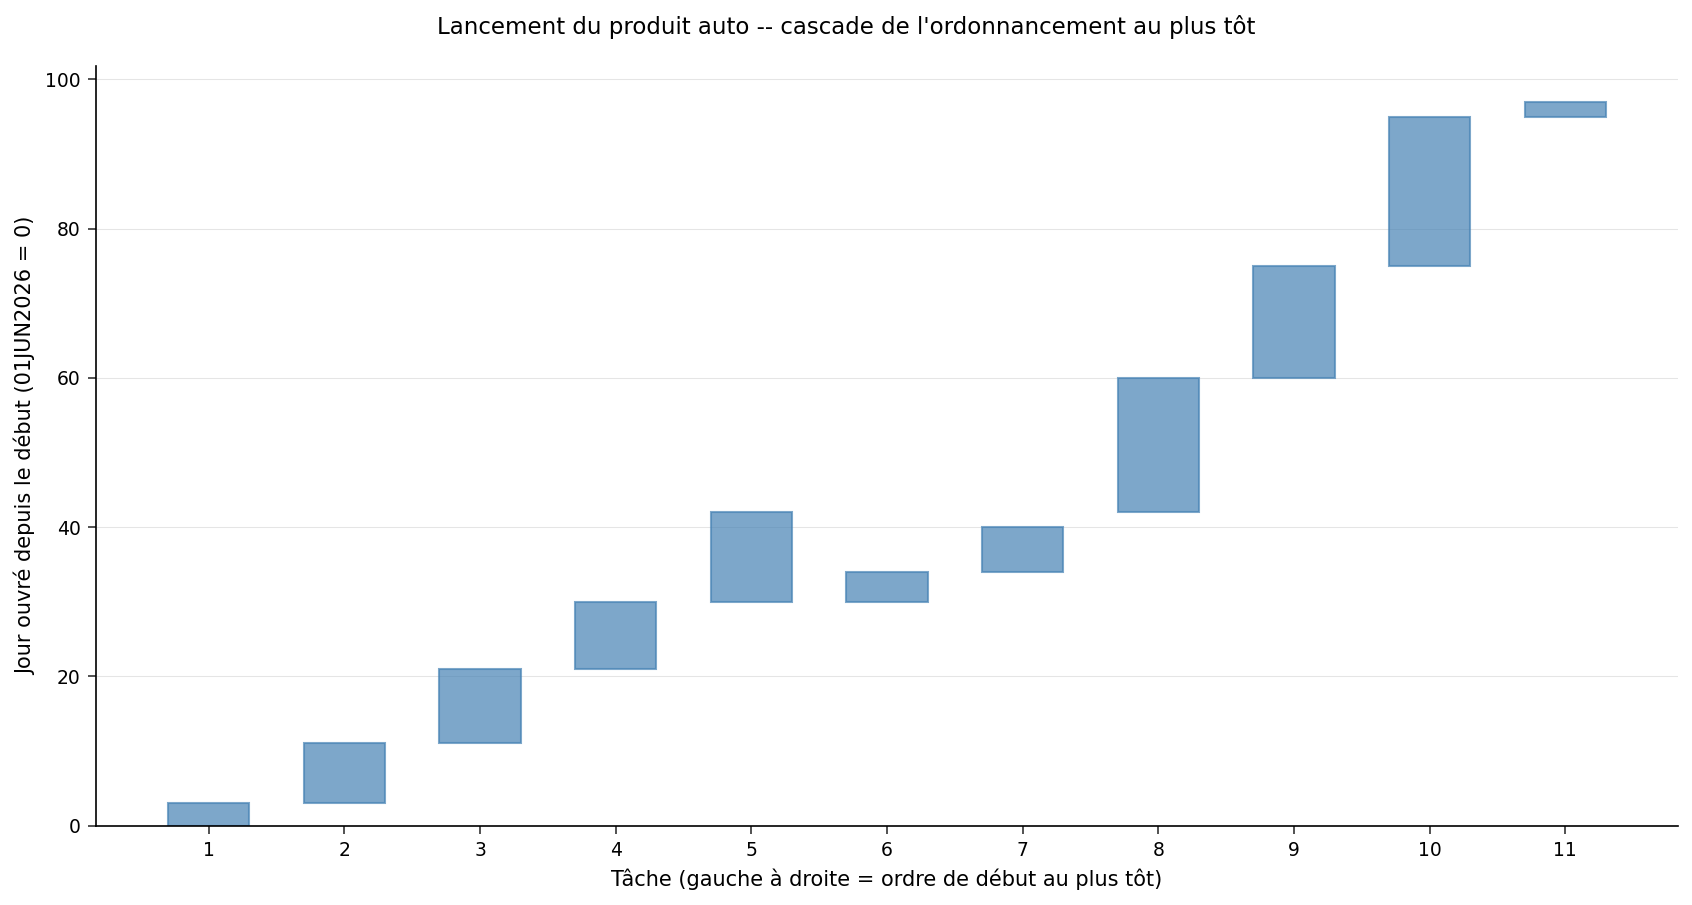

In [8]:
DONNÉES gantt; DÉFINIR sched_es;
   ord = es;          /* x numérique = ordre de début au plus tôt */
EXÉCUTER;
PROCÉDURE TRIER DONNÉES=gantt; PAR ord activity; EXÉCUTER;
DONNÉES gantt; DÉFINIR gantt; ax = _n_; EXÉCUTER;   /* index x compact 1..11 */

ODS GRAPHICS SUR / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TITRE "Lancement du produit auto -- cascade de l'ordonnancement au plus tôt";
PROCÉDURE SGPLOT DONNÉES=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS ÉTIQUETTE='Tâche (gauche à droite = ordre de début au plus tôt)'
         integer VALUES=(1 JUSQU_À 11 PAR 1);
   YAXIS ÉTIQUETTE='Jour ouvré depuis le début (01JUN2026 = 0)' grid;
EXÉCUTER;
ODS GRAPHICS OFF;

En lisant de gauche à droite, les barres montent continûment le long de la chaîne critique. Les deux tâches dont les barres rompent l'escalier -- démarrant plus bas que le sommet de la barre précédente -- sont le dépôt tarifaire et l'agrément, les activités qui portent la marge.


## Marge totale par tâche

Tracer la marge totale de chaque tâche rend le chemin critique incontestable : chaque tâche critique se situe à zéro, et seules les deux tâches réglementaires s'élèvent au-dessus.


                                  Marge totale par tâche (0 = sur le chemin critique)                                   




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Marge totale par tâche (0 = sur le chemin critique).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


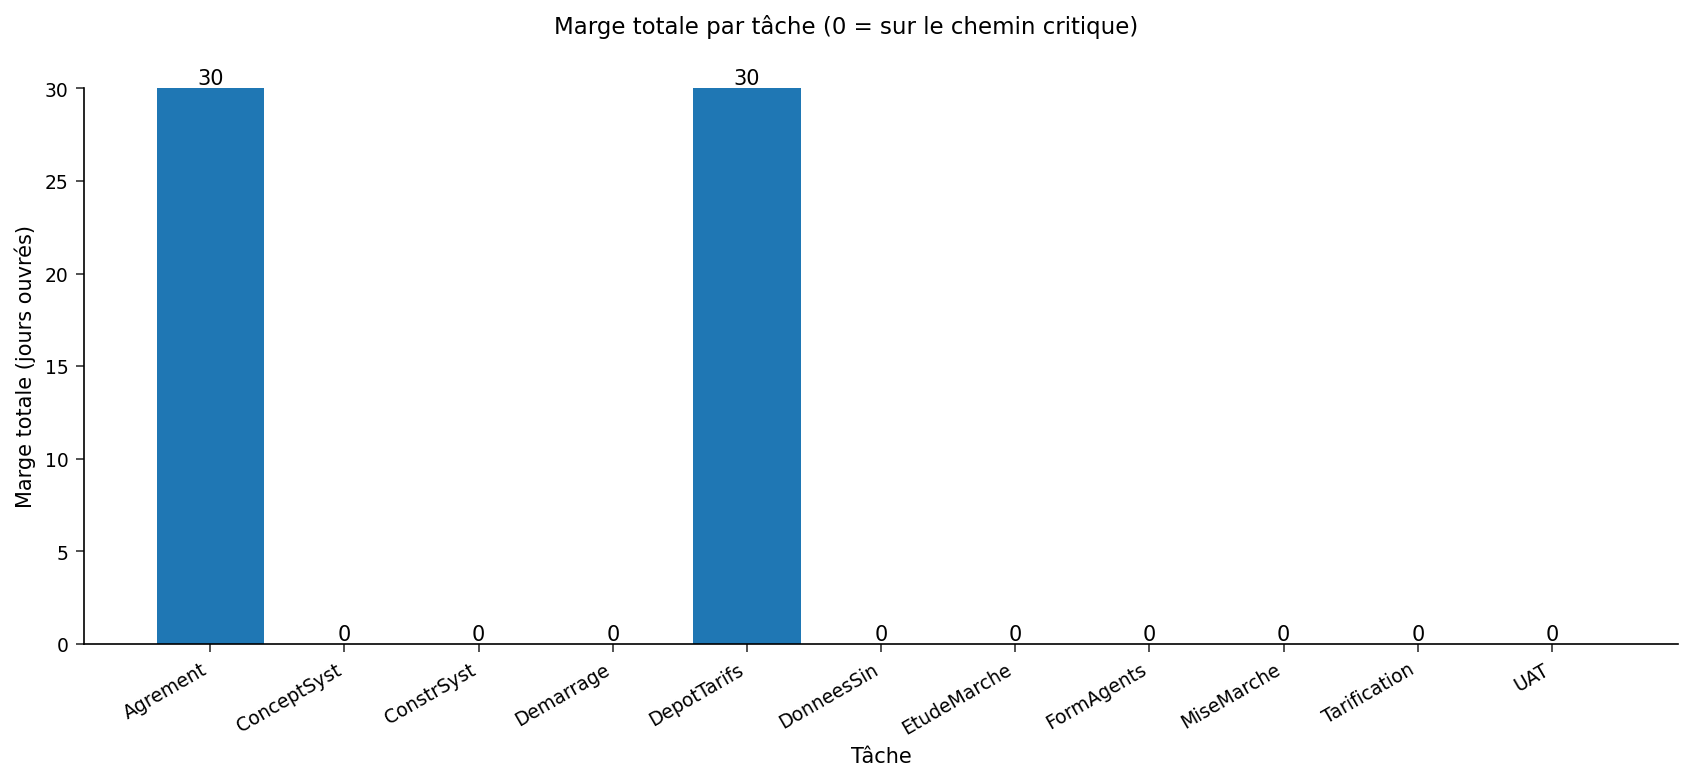

In [9]:
ODS GRAPHICS SUR / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TITRE 'Marge totale par tâche (0 = sur le chemin critique)';
PROCÉDURE SGPLOT DONNÉES=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS ÉTIQUETTE='Tâche' fitpolicy=rotatethin;
   YAXIS ÉTIQUETTE='Marge totale (jours ouvrés)';
EXÉCUTER;
ODS GRAPHICS OFF;

## Charge de ressources sous l'ordonnancement au plus tôt

Au-delà du calendrier, le plan met en concurrence deux viviers de spécialistes. Étendre chaque tâche sur les jours ouvrés qu'elle occupe et sommer la demande quotidienne donne le profil de charge des ressources -- combien d'actuaires et de développeurs le plan nécessite chaque jour si chaque tâche démarre au plus tôt. Le pic est la capacité maximale que le programme exige à un instant donné.


                        Charge quotidienne maximale des ressources (ordonnancement au plus tôt)                         

                                                  The MEANS Procedure

 Variable    Label             Maximum
 -------------------------------------
 ACTUARIES   Actuaires               3
 DEVELOPERS  Développeurs            3
 -------------------------------------

                     Charge quotidienne des actuaires et développeurs (ordonnancement au plus tôt)                      




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Charge quotidienne maximale des ressources (ordonnancement au plus tôt).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Charge quotidienne des actuaires et développeurs (ordonnancement au plus tôt).
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


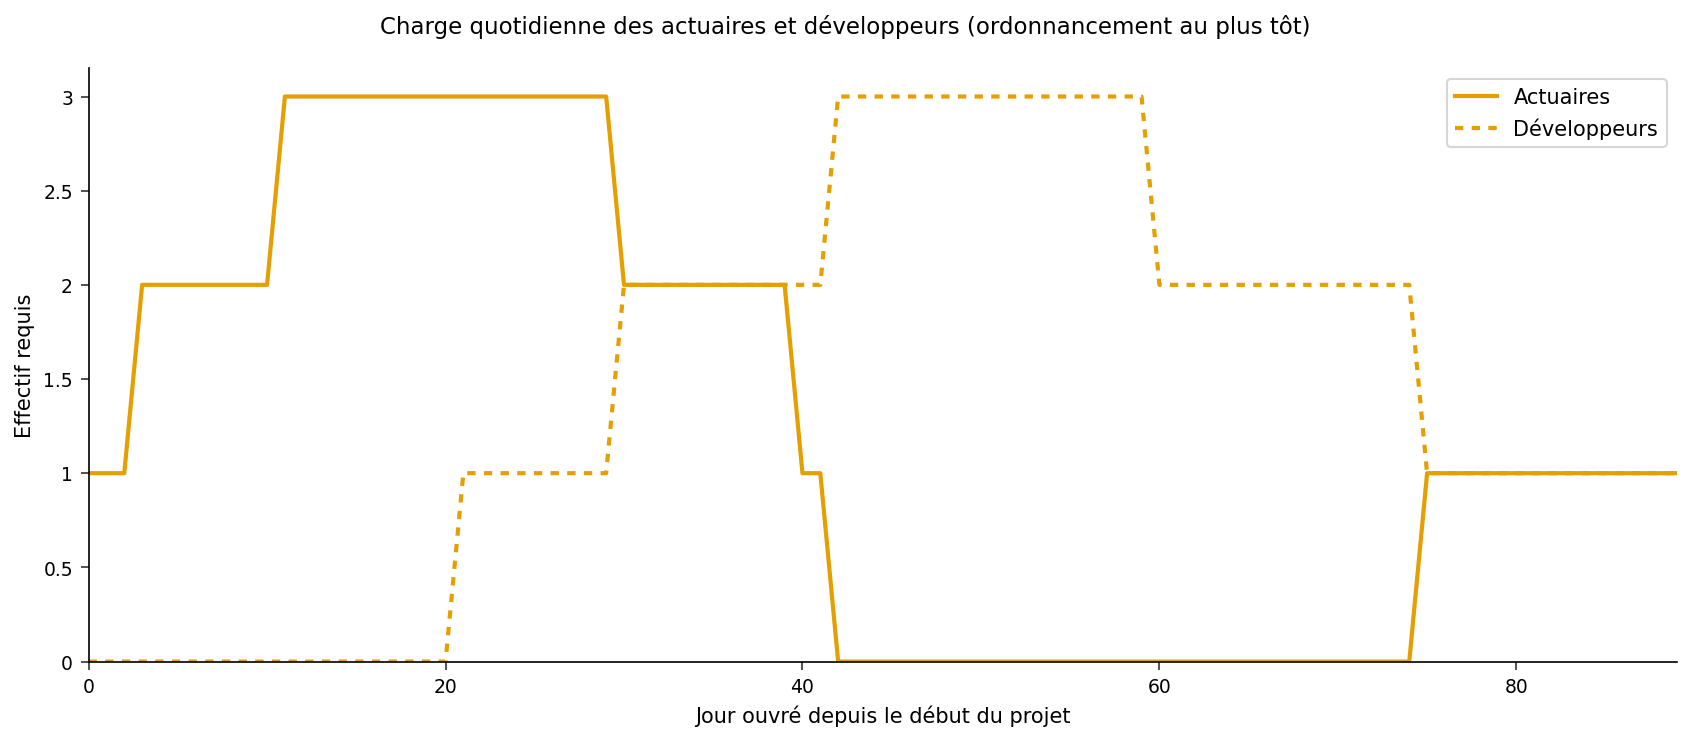

In [10]:
DONNÉES LOAD;
   DÉFINIR sched;
   FAIRE d = es JUSQU_À ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      SORTIE;
   FIN;
   GARDER day a_use d_use;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=LOAD SANS_IMPRESSION NWAY;
   CLASSE day;
   VAR a_use d_use;
   SORTIE out=rprofile(SUPPRIMER=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
EXÉCUTER;
PROCÉDURE TRIER DONNÉES=rprofile; PAR day; EXÉCUTER;

TITRE 'Charge quotidienne maximale des ressources (ordonnancement au plus tôt)';
PROCÉDURE MOYENNES DONNÉES=rprofile MAX maxdec=0;
   VAR actuaries developers;
   ÉTIQUETTE actuaries='Actuaires' developers='Développeurs';
EXÉCUTER;

ODS GRAPHICS SUR / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TITRE 'Charge quotidienne des actuaires et développeurs (ordonnancement au plus tôt)';
PROCÉDURE SGPLOT DONNÉES=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Actuaires';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Développeurs';
   XAXIS ÉTIQUETTE='Jour ouvré depuis le début du projet';
   YAXIS ÉTIQUETTE='Effectif requis' MIN=0;
   keylegend / location=inside position=topright;
EXÉCUTER;
ODS GRAPHICS OFF;

## Interprétation des résultats

- **La date de lancement est fixée par la voie de construction, pas par la voie réglementaire.** Le chemin critique passe par Lancement -> Étude de marché -> Assemblage des données de sinistres -> Tarification -> Conception du système -> Construction du système -> UAT -> Formation des agents -> Mise en marché, pour une durée totale de 97 jours ouvrés (se terminant le 13OCT2026). Chacune de ces tâches a une marge nulle, si bien que tout retard sur elles repousse le lancement au jour près.

- **La branche réglementaire dispose d'un mois de jeu.** Le dépôt tarifaire et l'agrément portent chacun 30 jours ouvrés de marge totale. Une fois la tarification terminée, ils peuvent démarrer aussi tard que leurs dates de début au plus tard et rejoindre néanmoins la formation des agents à temps, parce que la branche parallèle de construction du système (conception du système -> construction du système -> UAT) est la plus longue des deux voies alimentant le lancement. En termes de planification, le dépôt n'est *pas* la contrainte déterminante ici -- c'est la construction du système de gestion des polices.

- **La demande de spécialistes culmine à des phases différentes.** Le profil de charge montre la demande d'actuaires culminant tôt (jusqu'à la tarification) et la demande de développeurs culminant plus tard (jusqu'à la construction du système), chacune plafonnant à trois personnes par jour. Comme les deux pics tombent à des phases différentes, une équipe de spécialistes restreinte et séquentielle peut assurer le plan -- le programme n'a pas besoin de son effectif maximal d'actuaires et de développeurs simultanément.

**Enseignement métier.** La CPM transforme une liste de tâches de lancement en un ordonnancement actionnable : elle identifie les activités de la voie de construction que l'assureur doit protéger pour atteindre le 13OCT2026, quantifie le mois de jeu disponible sur le dépôt réglementaire, et montre que le décalage des pics d'actuaires et de développeurs permet à une équipe de spécialistes réduite de livrer le plan.

*Note d'implémentation :* SAS calcule ceci avec PROC CPM (SAS/OR). Jenner atteint le même résultat de chemin critique avant/arrière avec PROC OPTMODEL en résolvant les deux programmes linéaires de plus long chemin qui sous-tendent la méthode.
